## Mod 1 Week 8 Live Session Demos


#### A dataset with N features is a vector in N-Dimensional Space

#### Here N = 3:

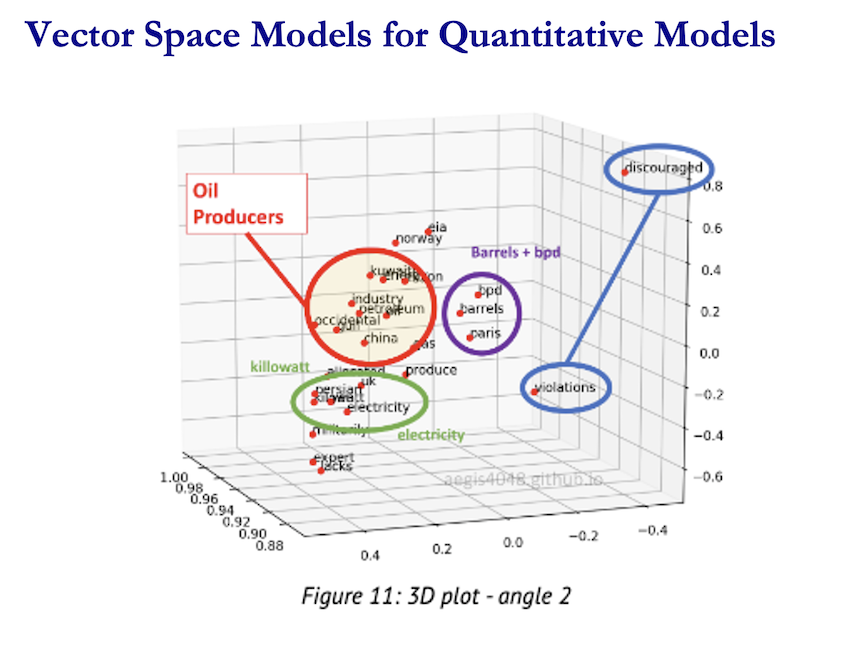

## Linear Algebra in Natural Language Processing

### Word and Document Embeddings

#### Linguistic objects (words, sentences, documents) can be calculated as vectors in a vector space, using techniques we'll study in Module 7. 




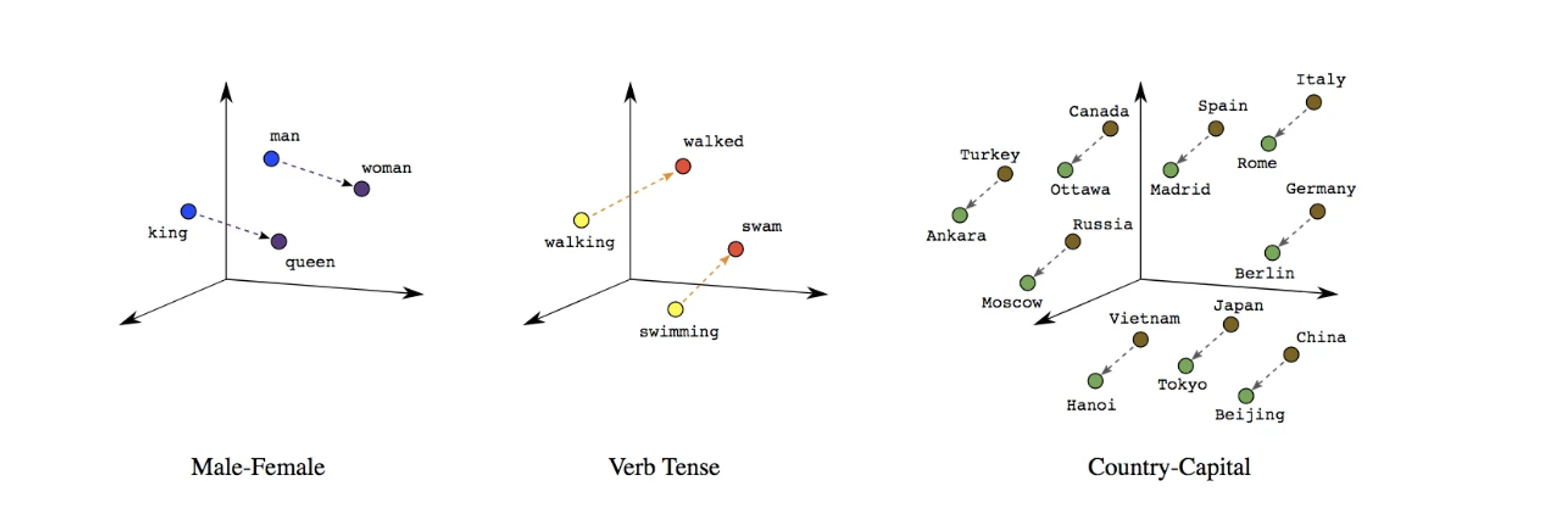

---

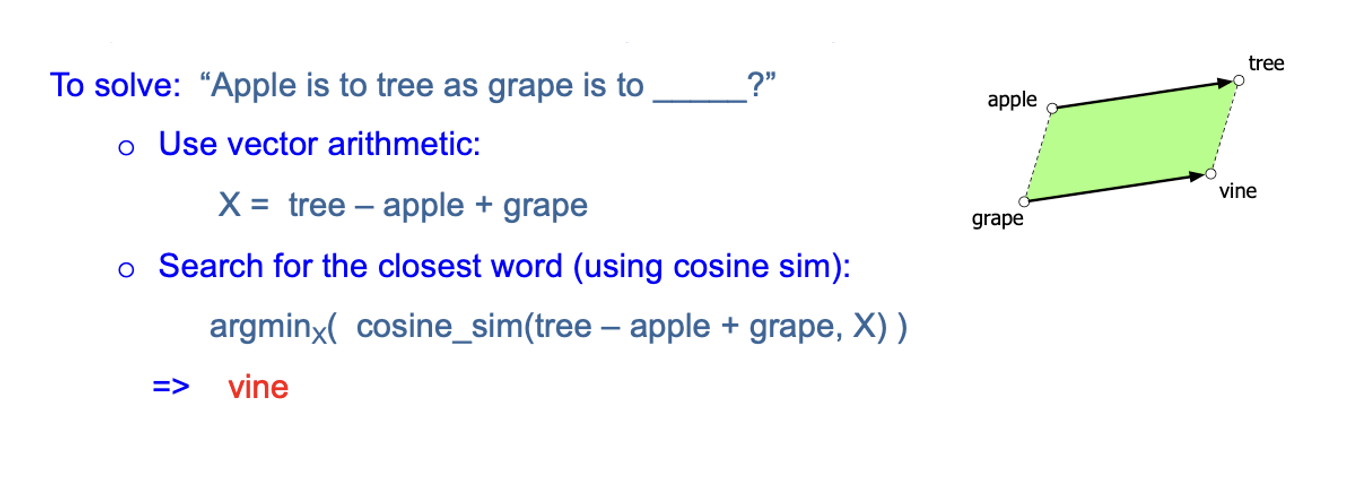

---

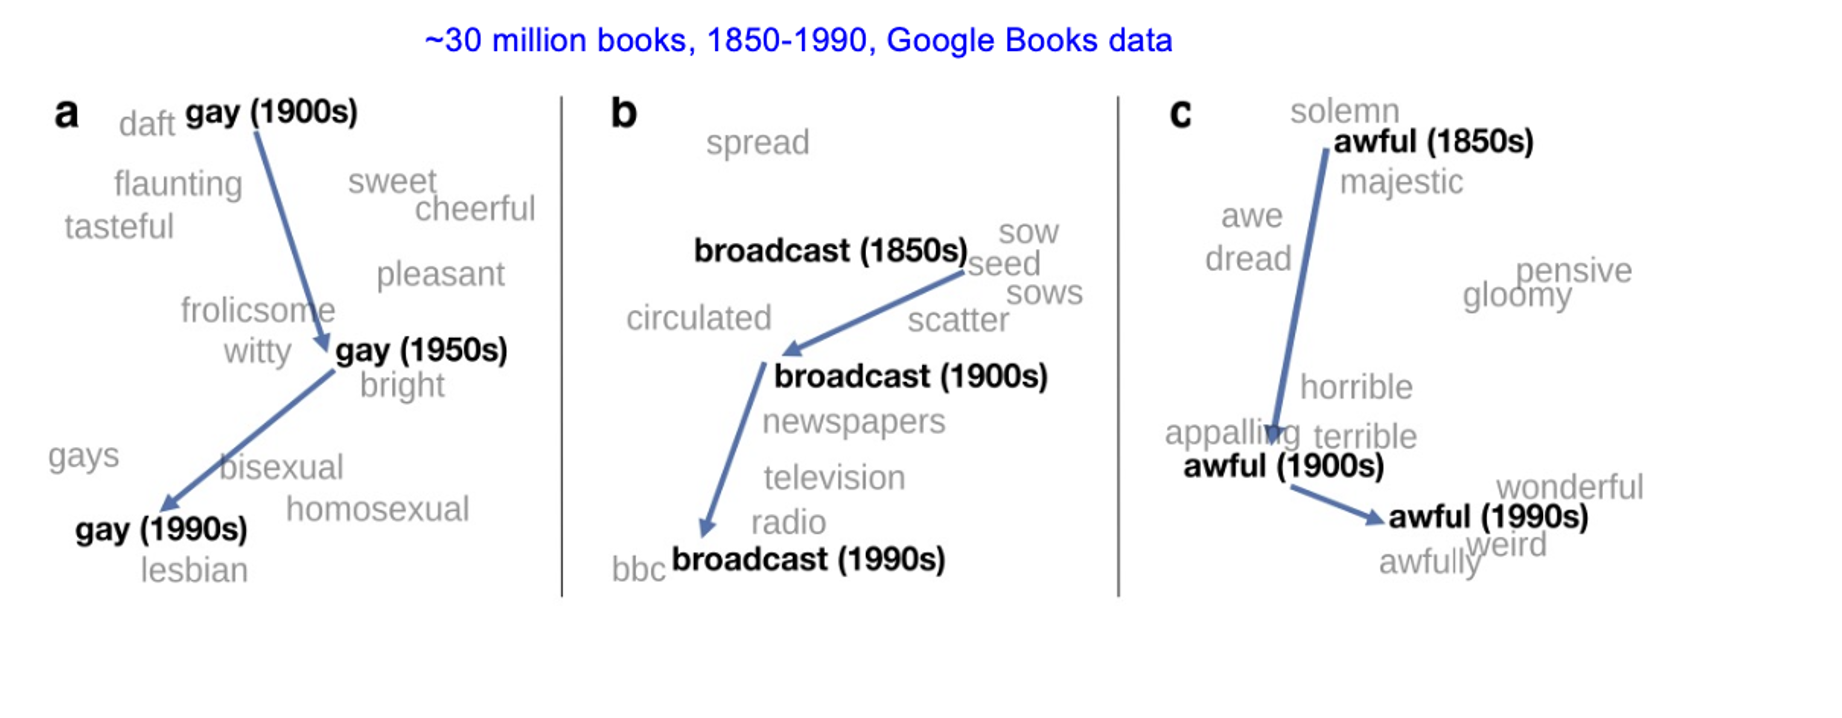

#### Principal Components Analysis of Text

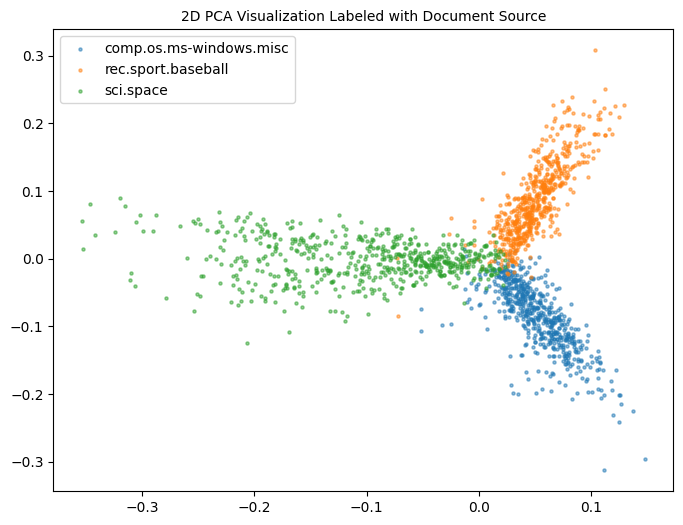

In [3]:
import numpy as np

from sklearn.datasets import fetch_20newsgroups
categories = ['comp.os.ms-windows.misc', 'sci.space', 'rec.sport.baseball']
news_data = fetch_20newsgroups(subset='train', categories=categories)

# news_data.data is a list of strings, one for each message to a newsgroup


from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
dtm = vectorizer.fit_transform(news_data.data).todense()

# dtm.shape = (1781, 57522)
centered_dtm = dtm - np.mean(dtm, axis=0)
u, s, vt = np.linalg.svd(centered_dtm)

Xk = u @ np.diag(s)
fig, ax = plt.subplots(1,1,figsize=(8,6))
for i, label in enumerate(set(news_data.target)):
        point_indices = np.where(news_data.target == label)[0]
        plt.scatter(np.ravel(Xk[point_indices,0]), np.ravel(Xk[point_indices,1]), 
                    s=20, alpha=0.5, marker='.', label=news_data.target_names[i])
plt.legend(loc='best')
plt.title('2D PCA Visualization Labeled with Document Source', size=10);

PC1 explained variance: 0.78%


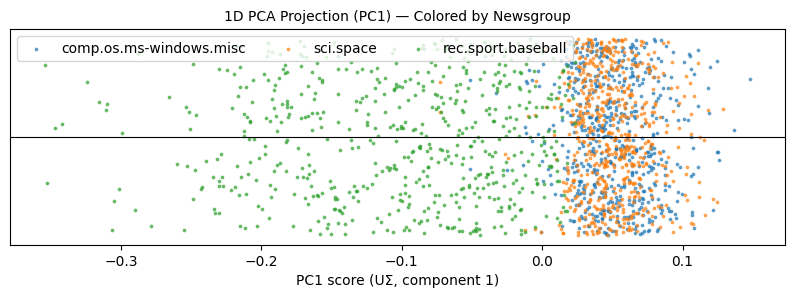

In [4]:
# --- keep your code above unchanged ---

Xk = u @ np.diag(s)              # PCA scores (UΣ)
pc1 = np.ravel(Xk[:, 0])         # 1D scores along PC1

# (optional) how much variance PC1 explains
expl_var_pc1 = (s[0]**2) / np.sum(s**2)
print(f"PC1 explained variance: {expl_var_pc1:.2%}")

# --- 1D plot: points on a line (tiny jitter only to reduce overdraw) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axhline(0, linewidth=0.8, color='k')

for i, name in enumerate(categories):
    idx = np.where(news_data.target == i)[0]
    jitter = (np.random.rand(len(idx)) - 0.5) * 0.01   # ~zero; remove if you want a perfect line
    ax.scatter(pc1[idx], 0 + jitter, s=12, alpha=0.6, marker='.', label=name)

ax.set_yticks([])                 # hide y-axis; it's just a line
ax.set_xlabel('PC1 score (UΣ, component 1)')
ax.set_title('1D PCA Projection (PC1) — Colored by Newsgroup', fontsize=10)
ax.legend(loc='upper left', ncol=3, frameon=True)
plt.show()


Explained variance PC1–3: 2.09% (PC1 0.78%, PC2 0.72%, PC3 0.58%)


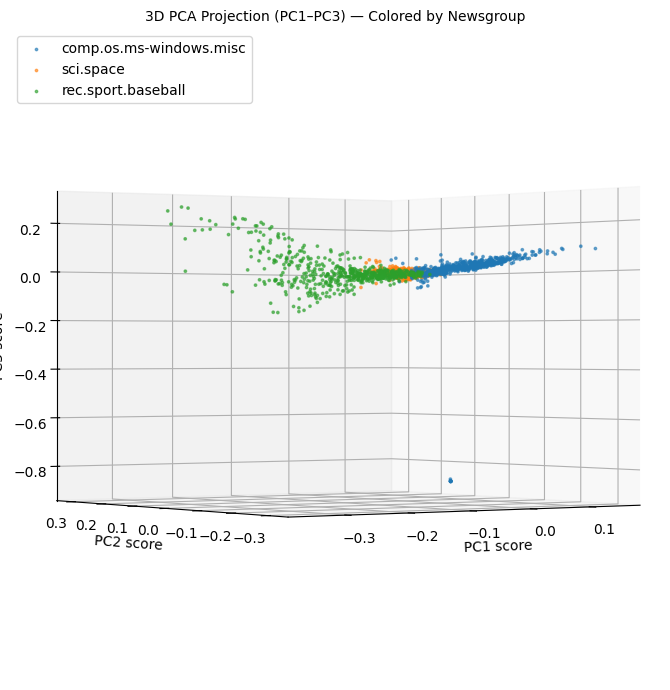

In [21]:
# --- keep everything above unchanged (through SVD) ---

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# Scores (PCA coordinates). Make sure it's an ndarray (not np.matrix)
Xk = np.asarray(u @ np.diag(s))
pcs3 = Xk[:, :3]  # PC1, PC2, PC3

# (optional) explained variance for the first 3 PCs
evr3 = (s[:3]**2) / np.sum(s**2)
print(f"Explained variance PC1–3: {evr3.sum():.2%} "
      f"(PC1 {evr3[0]:.2%}, PC2 {evr3[1]:.2%}, PC3 {evr3[2]:.2%})")

# --- 3D scatter ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

handles = []
for i, name in enumerate(categories):
    idx = np.where(news_data.target == i)[0]
    h = ax.scatter(
        np.ravel(pcs3[idx, 0]),   # PC1
        np.ravel(pcs3[idx, 1]),   # PC2
        np.ravel(pcs3[idx, 2]),   # PC3
        s=12, alpha=0.6, marker='.', label=name
    )
    handles.append(h)

ax.set_xlabel('PC1 score')
ax.set_ylabel('PC2 score')
ax.set_zlabel('PC3 score')
ax.view_init(elev=0, azim=235)  # adjust viewing angle if you like
ax.legend(handles=handles, loc='upper left')
ax.set_title('3D PCA Projection (PC1–PC3) — Colored by Newsgroup', fontsize=10)
plt.tight_layout()
plt.show()


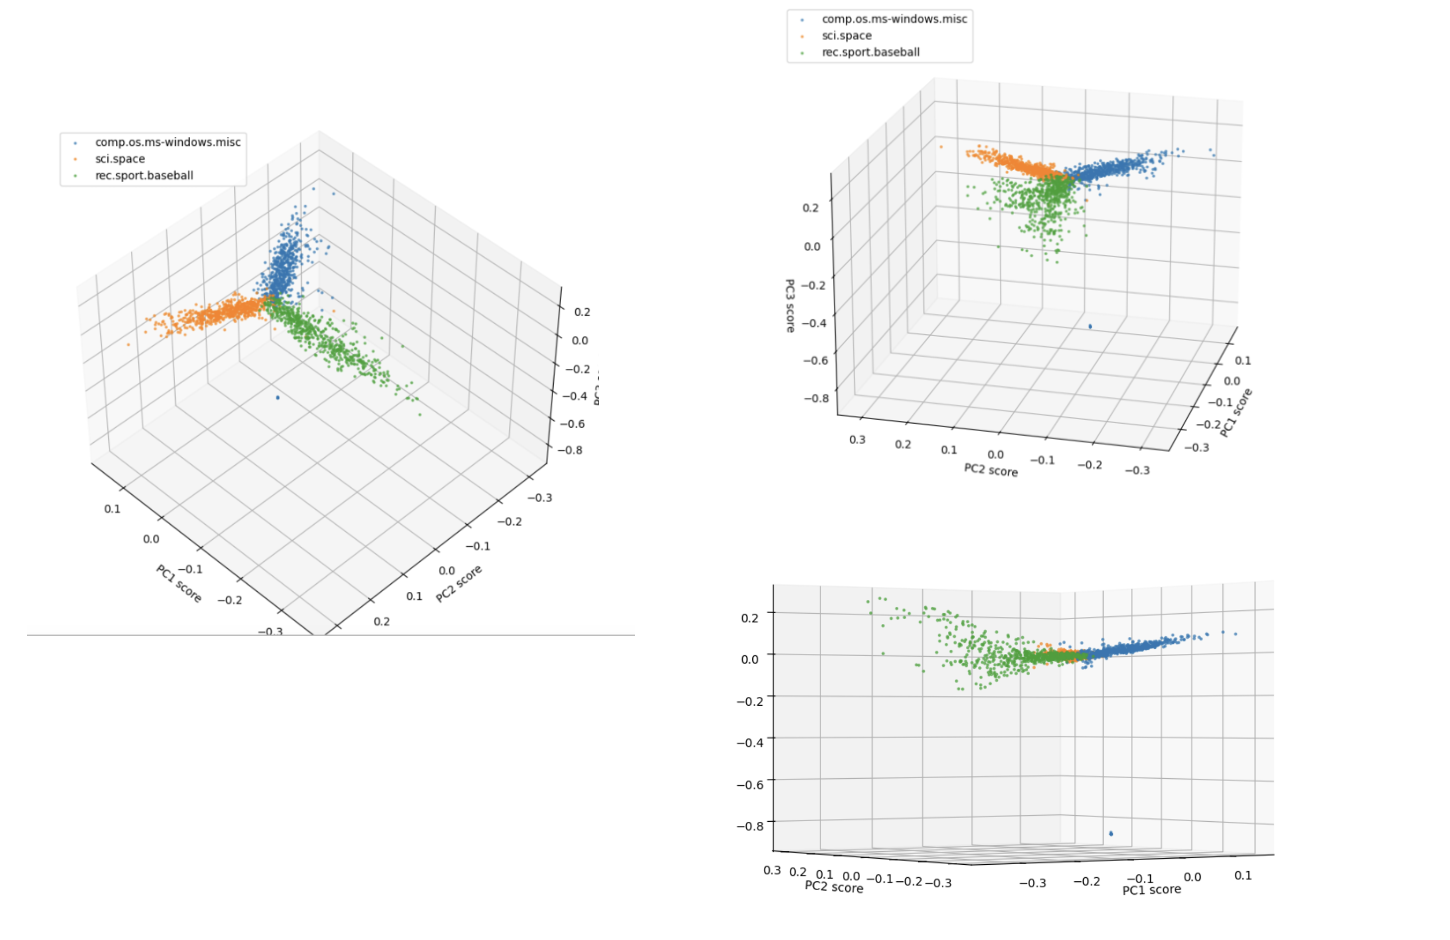

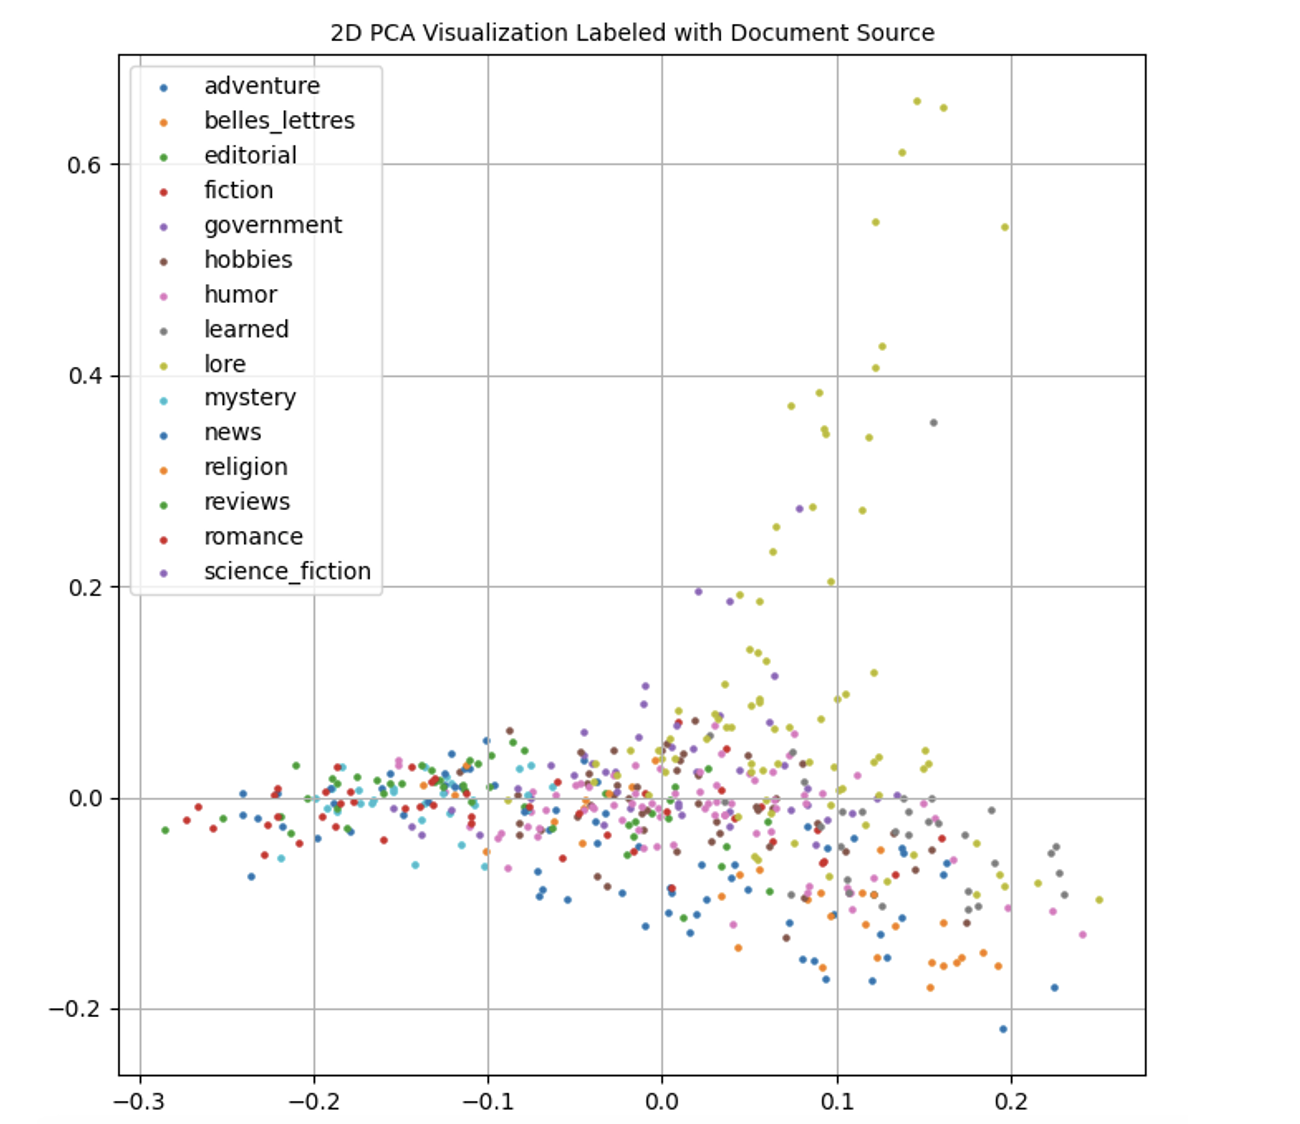

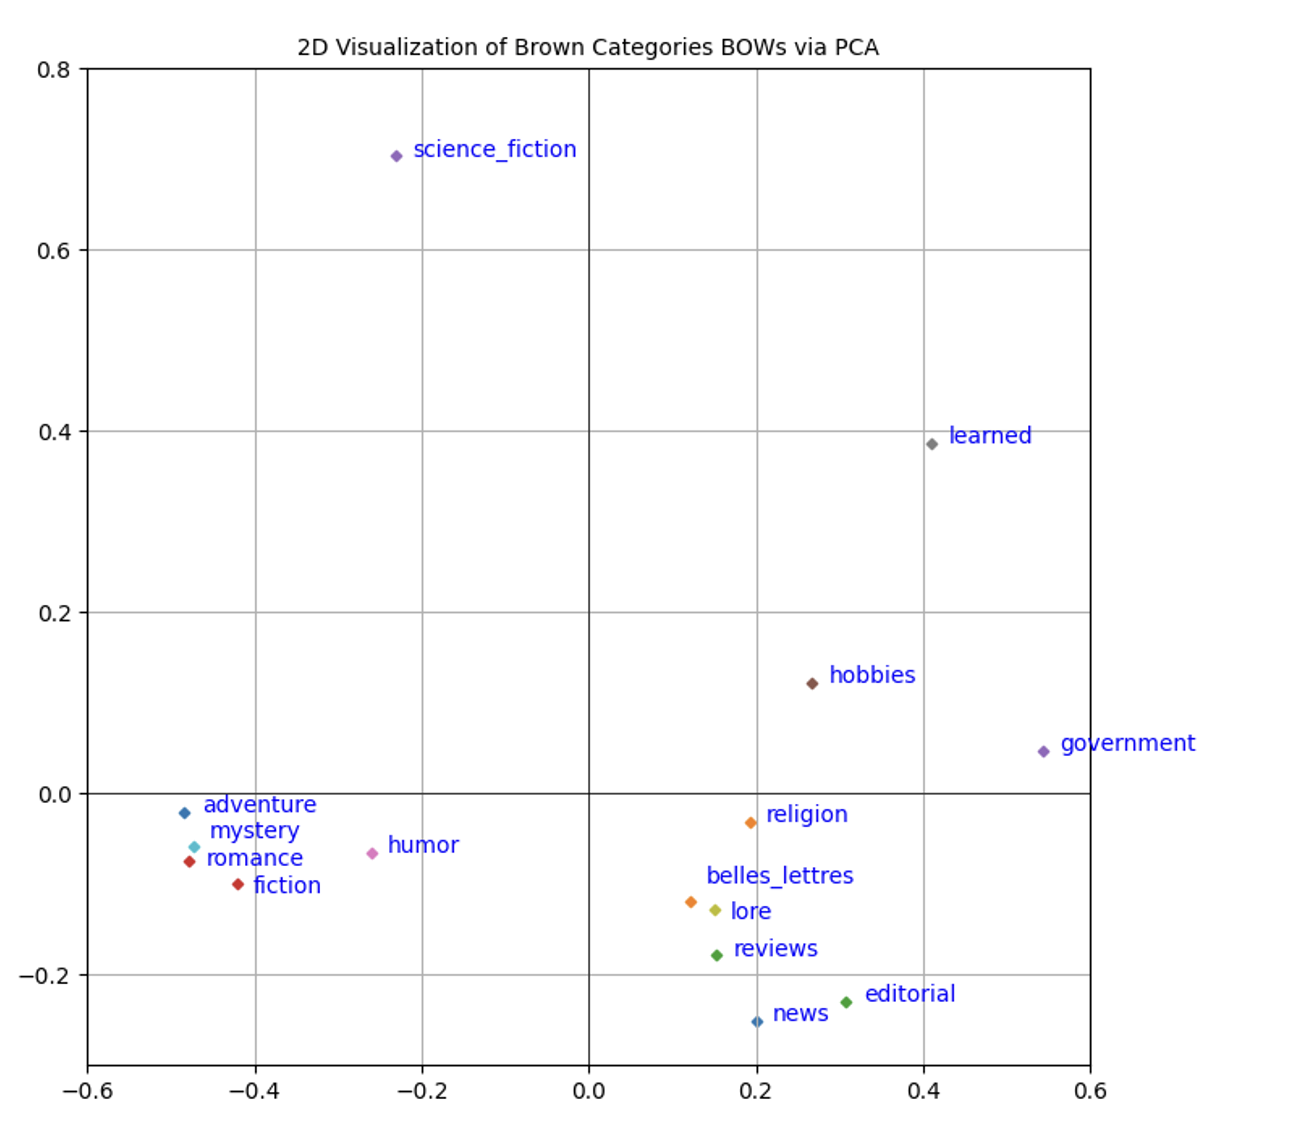

### PCA on Shakespeare


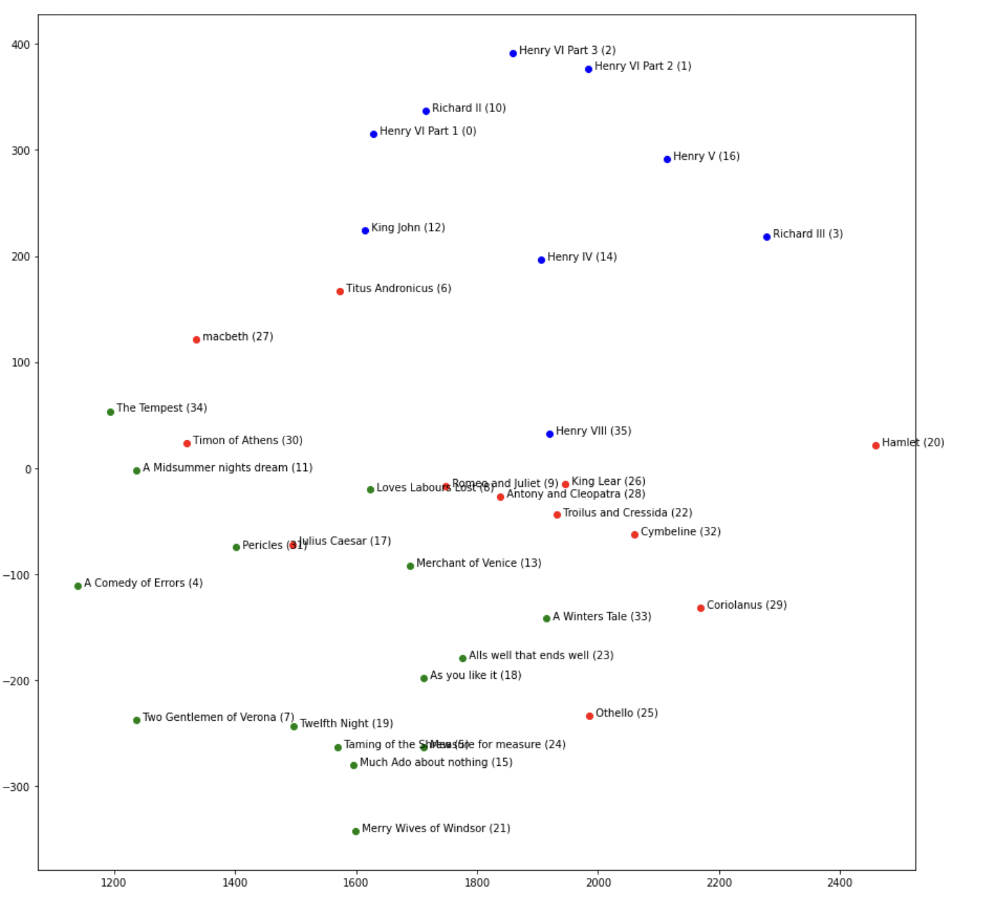

### Matrix Multiplication and Linear Models!


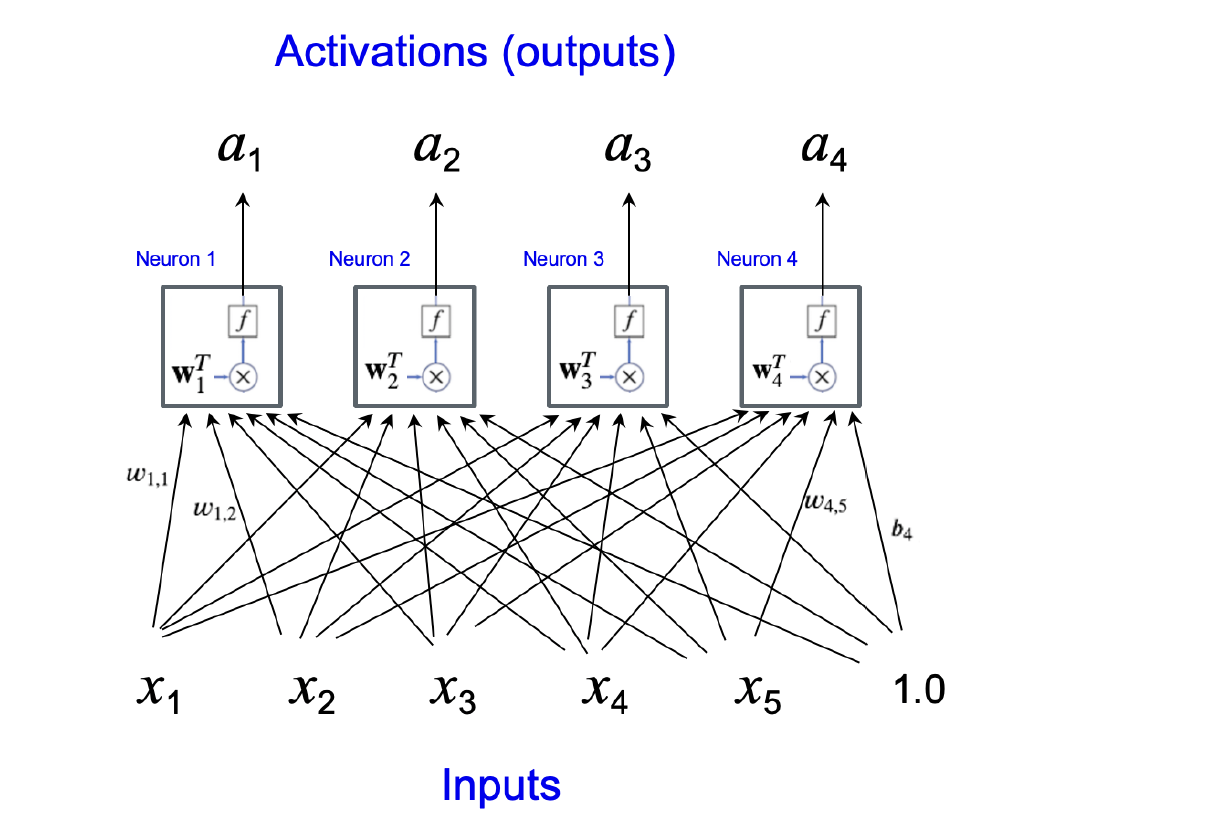

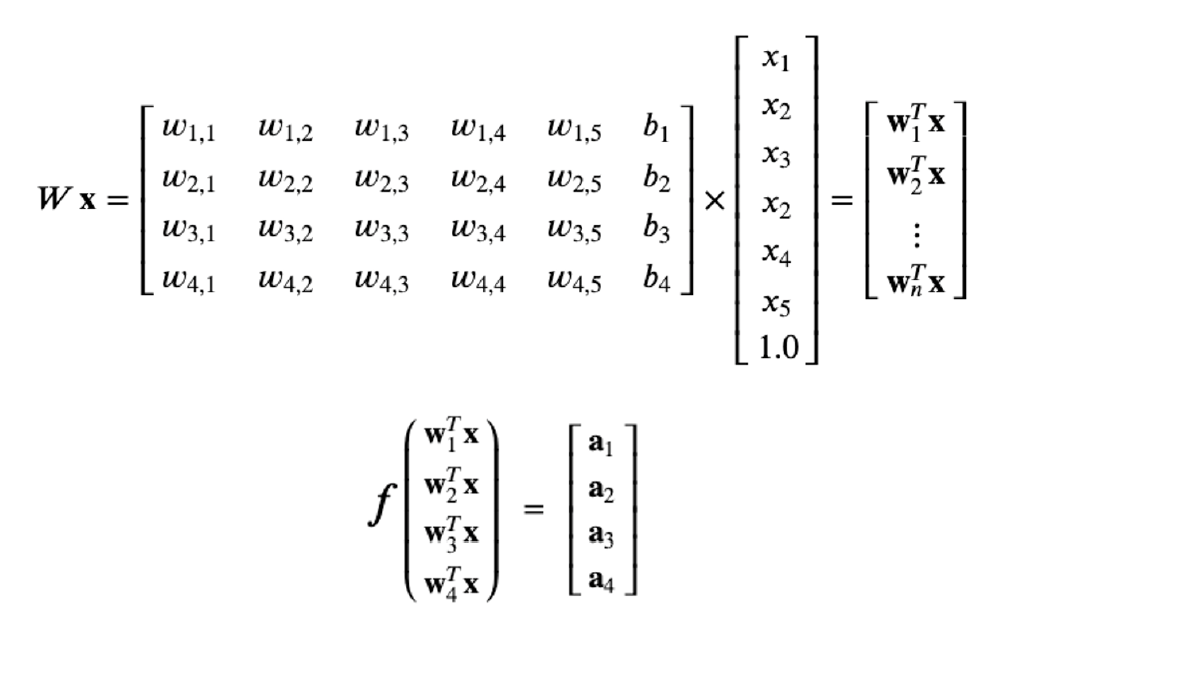

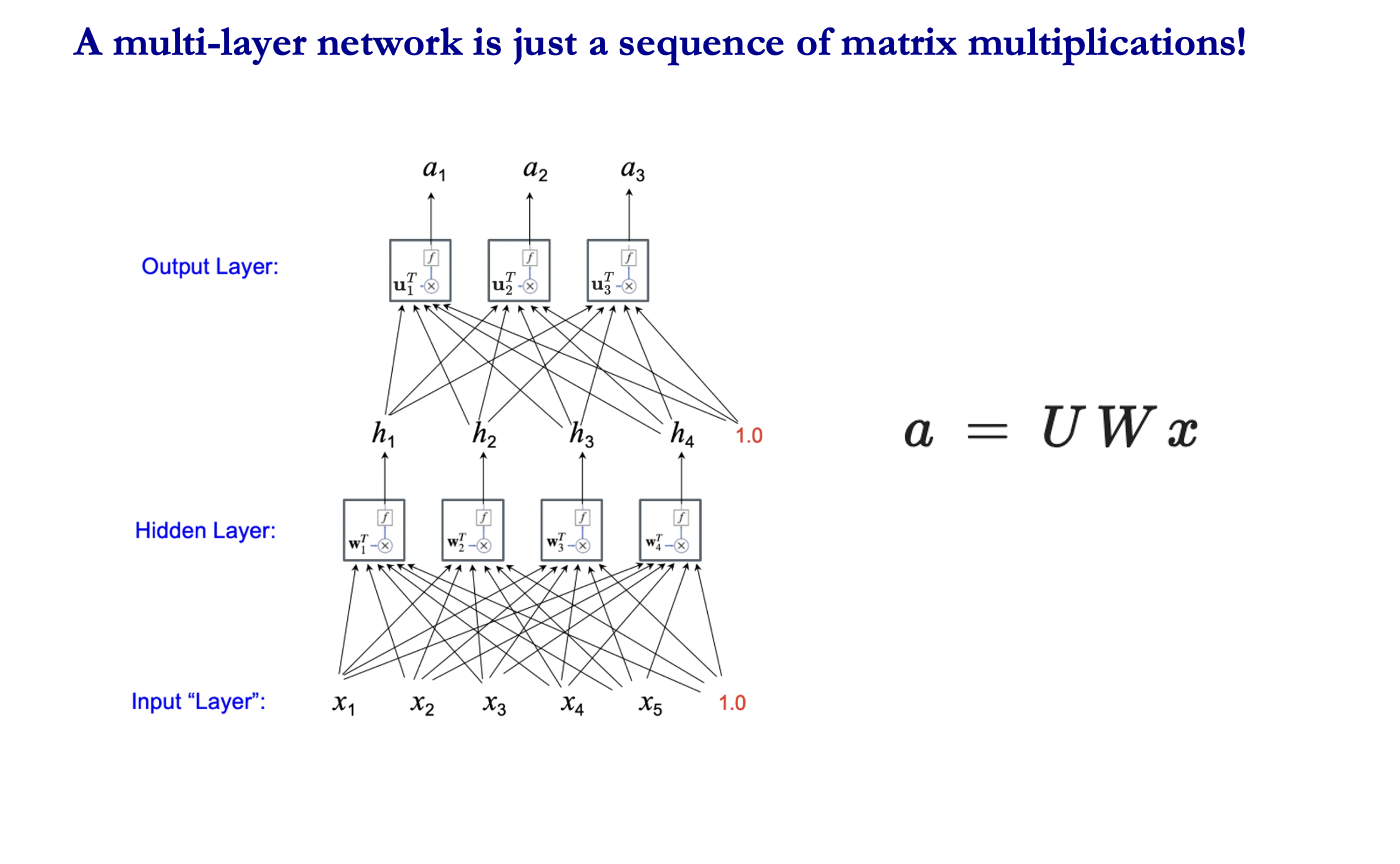